*Submitted by:*

Marina Engelhardt

Soolu Thomas

In [ ]:
# !pip install pyLDAvis
# !pip install nltk
# !pip install scikit-fuzzy
# !pip install -U pandas-profiling
# !pip install hdbscan
# # !pip uninstall umap
# !pip install umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 24.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 390.9/390.9 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 53.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 686.1/686.1 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.8/104.8 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 37.2 MB/s eta 0:00:00
  Created wheel for htmlmin: filename=htmlmin-0.1.12-py3-none-any.whl size=27081 sha256=75ad16b806692092f961b9b50ae6eb94c6b46282430f74c029f9a0cc99b8dc76
  Stored in directory: /root/.cache/pip/wheels/dd/91/29/a79cecb328d01739e64017b6fb9a1ab9d8

In [ ]:
# !pip uninstall numpy
# !pip uninstall pandas

# !pip install --user numpy
# !pip install --user  pandas

In [ ]:
import re
import string
import numpy as np
import pandas as pd
import random
from time import sleep
import time
from pathlib import Path
import joblib
import os
import collections
from functools import wraps
from os.path import getsize

# text pre-processing and vectorization
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import RegexpTokenizer
from nltk.tokenize import word_tokenize
from sklearn.preprocessing import normalize
nltk.download('stopwords')
nltk.download('punkt')
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import NMF, LatentDirichletAllocation

# evaluation
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import make_scorer
from sklearn.metrics import silhouette_score, silhouette_samples
from yellowbrick.cluster import SilhouetteVisualizer

# models
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
import skfuzzy as fuzz
import scipy.cluster.hierarchy as shc
import hdbscan

# feature reduction
from sklearn.decomposition import PCA
import umap.umap_ as umap
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

# visualization
from yellowbrick.cluster import KElbowVisualizer
from pprint import pprint
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns
sns.set()
import pyLDAvis
import pyLDAvis.sklearn
pyLDAvis.enable_notebook()

import warnings
warnings.filterwarnings("ignore")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


/usr/local/lib/python3.7/dist-packages/past/types/oldstr.py:5: DeprecationWarning: Using or importing the ABCs from 'collections' instead of from 'collections.abc' is deprecated since Python 3.3,and in 3.9 it will stop working
  from collections import Iterable
/usr/local/lib/python3.7/dist-packages/past/builtins/misc.py:4: DeprecationWarning: Using or importing the ABCs from 'collections' instead of from 'collections.abc' is deprecated since Python 3.3,and in 3.9 it will stop working
  from collections import Mapping


In [ ]:
# mount your google drive
from google.colab import drive
drive.mount('/content/drive')

ROOT = Path(r'/content/')
MY_GOOGLE_DRIVE = ROOT/'drive/My Drive'


Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Classification and exploration of the topics within pations' data based on medical creation conditions.   

**Approach:**

**Baseline Topic Analysis:**
- Utilized CountVectorizer to create bag-of-words representations.
- Applied LDA (Latent Dirichlet Allocation) for initial topic modeling, establishing a baseline understanding of the dominant topics in the dataset.  

**Enhanced Topic Classification:**
- Transitioned to TF-IDF vectorization to capture word importance more effectively across documents.
- Implemented clustering algorithms (i.e., K-Means, hierarchical, HDBSCAN clustering) to further refine topic classification and group data by themes.

# I. Data Processing

## 1. Loading data

In [ ]:
# load data
excl_depr = pd.read_csv('exclusion/Depression.txt', sep="\t")
print('Exclusion: Depression data set dimentions: ', excl_depr.shape)
print('Number of missing values: \n', excl_depr.isnull().sum())
excl_depr.head()

Exclusion: Depression data set dimentions:  (12884, 7)
Number of missing values: 
 NCT#             0
phase         7884
condition        0
sponsor          0
start_date       0
mesh_list       40
criterion        0
dtype: int64


,NCT#,phase,condition,sponsor,start_date,mesh_list,criterion
0,NCT00000378,Phase 4,Depression;Melancholia,New York State Psychiatric Institute,"February 10, 2015",Depression;Depressive Disorder,- Patients with the following symptoms or con...
1,NCT00000390,Phase 2,Depression,GEIGY Pharmaceuticals,"February 10, 2015",Depression;Depressive Disorder,Non ambulatory patients or those requiring ext...
2,NCT00000390,Phase 2,Depression,GEIGY Pharmaceuticals,"February 10, 2015",Depression;Depressive Disorder,Non ambulatory patients or those requiring ext...
3,NCT00000390,Phase 2,Depression,GEIGY Pharmaceuticals,"February 10, 2015",Depression;Depressive Disorder,Current alcohol or drug abuse.
4,NCT00000390,Phase 2,Depression,GEIGY Pharmaceuticals,"February 10, 2015",Depression;Depressive Disorder,Unspecified


In [ ]:
excl_depr.groupby('phase')['condition'].nunique()

phase
Early Phase 1       13
Phase 1             55
Phase 1/Phase 2     25
Phase 2             91
Phase 2/Phase 3     27
Phase 3             77
Phase 4            108
Name: condition, dtype: int64

In [ ]:
# load data for inclusion
incl_depr = pd.read_csv('inclusion/Depression.txt', sep="\t")
print('Inclusion: Depression data set dimentions: ', incl_depr.shape)
print('Number of missing values: \n', incl_depr.isnull().sum())
incl_depr.head()

Inclusion: Depression data set dimentions:  (9512, 7)
Number of missing values: 
 NCT#             0
phase         6692
condition        0
sponsor          0
start_date       0
mesh_list       57
criterion        0
dtype: int64


,NCT#,phase,condition,sponsor,start_date,mesh_list,criterion
0,NCT00000367,NaN,Depression,Weill Medical College of Cornell University,"February 10, 2015",Depression,- Patients must have: Depressive symptoms and...
1,NCT00000376,NaN,Depression;Anxiety Disorders;Personality Disor...,University of Pennsylvania,"February 10, 2015",Disease;Depression;Depressive Disorder;Anxiety...,- Patients must have: Drug-resistant depressi...
2,NCT00000377,NaN,Depression,University of Pittsburgh,"February 10, 2015",Depression;Depressive Disorder,- Patients must have: Recurrence of major dep...
3,NCT00000378,Phase 4,Depression;Melancholia,New York State Psychiatric Institute,"February 10, 2015",Depression;Depressive Disorder,- Patients must have: Unipolar major depressi...
4,NCT00000390,Phase 2,Depression,GEIGY Pharmaceuticals,"February 10, 2015",Depression;Depressive Disorder,Patient must be ambulatory and relatively good...


In [ ]:
# load data
out_depr = pd.read_csv('outcome/Depression.txt', sep="\t")
print('Outcome: Depression data set dimentions: ', out_depr.shape)
print('Number of missing values: \n', out_depr.isnull().sum())
out_depr.head()

Outcome: Depression data set dimentions:  (18287, 10)
Number of missing values: 
 NCT#                0
phase           14314
condition        1535
sponsor          1535
start_date       1535
mesh_list        1641
outcome_type     1535
measure          1535
time_scale       1917
description      4504
dtype: int64


,NCT#,phase,condition,sponsor,start_date,mesh_list,outcome_type,measure,time_scale,description
0,NCT00000378,Phase 4,Depression;Melancholia,New York State Psychiatric Institute,"February 10, 2015",Depression;Depressive Disorder,primary,HAMILTON Rating Scale for DEPRESSION Range,BASELINE COMPARED TO 12 WEEK MEASUREMENT,"Hamilton scale range 0-40, values below 7 are ..."
1,NCT00004554,Phase 4,Alcoholism;Depression,University of Pennsylvania,"February 10, 2015",Alcoholism;Depression;Depressive Disorder,primary,"Subjects self-report of alcohol use, measured ...",14 weeks,NaN
2,NCT00005850,Phase 2,Anxiety Disorder;Depression;Fatigue;Lung Cancer,Alliance for Clinical Trials in Oncology,"February 10, 2015","Lung Neoplasms;Carcinoma, Non-Small-Cell Lung;...",primary,Change in the MHI-17 global psychological dist...,Up to 8 weeks,NaN
3,NCT00005850,Phase 2,Anxiety Disorder;Depression;Fatigue;Lung Cancer,Alliance for Clinical Trials in Oncology,"February 10, 2015","Lung Neoplasms;Carcinoma, Non-Small-Cell Lung;...",primary,Overall survival,Up to 2 years post-treatment,NaN
4,NCT00005850,Phase 2,Anxiety Disorder;Depression;Fatigue;Lung Cancer,Alliance for Clinical Trials in Oncology,"February 10, 2015","Lung Neoplasms;Carcinoma, Non-Small-Cell Lung;...",primary,Failure-free survival,Up to 2 years post-treatment,NaN


In [ ]:
# drop NaNs in the "Description" column
out_depr = out_depr.dropna(subset=['description'])
print('Outcome: Depression data set dimentions: ', out_depr.shape)
print('Number of missing values: \n', out_depr.isnull().sum())

Outcome: Depression data set dimentions:  (13783, 10)
Number of missing values: 
 NCT#                0
phase           11093
condition           0
sponsor             0
start_date          0
mesh_list         102
outcome_type        0
measure             0
time_scale          0
description         0
dtype: int64


## 2. Tokenizing Data

In [ ]:
STOPWORDS = stopwords.words("english")
SNOWBALL = nltk.stem.SnowballStemmer("english")

def clean_text(text:str) -> str:
    text = re.sub('(www\.[^\s]+)', '', text.lower()) # remove urls
    text = re.sub('(https?://[^\s]+)', '', text) # remove urls
    text = re.sub('@[^\s]+','', text) # remove hashtags
    text = re.sub('[\s]+', ' ', text) # consolidate white spaces
    text = re.sub(r'#([^\s]+)', r'\1', text) # remove pound signs
    return text

def remove_stop_words(text: str) -> str:
    words = word_tokenize(text)
    words_without_sw = [w for w in words if not w in STOPWORDS]
    return " ".join(words_without_sw)

def keep_stems_only(text:str)->str:
    words = word_tokenize(text)
    stems = [SNOWBALL.stem(w) for w in words]
    return " ".join(stems)

def preprocess(text:str)-> str:
    """put all together as a text preprocessing pipeline"""
    text = clean_text(text)
    text = remove_stop_words(text)
    text = keep_stems_only(text)
    return text

In [ ]:
path = MY_GOOGLE_DRIVE/"processed_excl.pkl"

# exclusion
if not path.exists():
    excl_depr['clean_criterion'] = excl_depr['criterion'].apply(preprocess)
    excl_depr.to_pickle(path) # save cleaned data

path = MY_GOOGLE_DRIVE/"processed_excl.pkl"
depr_excl_cl = pd.read_pickle(path)
depr_excl_cl.head()

,NCT#,phase,condition,sponsor,start_date,mesh_list,criterion,clean_criterion
0,NCT00000378,Phase 4,Depression;Melancholia,New York State Psychiatric Institute,"February 10, 2015",Depression;Depressive Disorder,- Patients with the following symptoms or con...,- patient follow symptom condit exclud : psych...
1,NCT00000390,Phase 2,Depression,GEIGY Pharmaceuticals,"February 10, 2015",Depression;Depressive Disorder,Non ambulatory patients or those requiring ext...,non ambulatori patient requir extens help self...
2,NCT00000390,Phase 2,Depression,GEIGY Pharmaceuticals,"February 10, 2015",Depression;Depressive Disorder,Non ambulatory patients or those requiring ext...,non ambulatori patient requir extens help self...
3,NCT00000390,Phase 2,Depression,GEIGY Pharmaceuticals,"February 10, 2015",Depression;Depressive Disorder,Current alcohol or drug abuse.,current alcohol drug abus .
4,NCT00000390,Phase 2,Depression,GEIGY Pharmaceuticals,"February 10, 2015",Depression;Depressive Disorder,Unspecified,unspecifi


In [ ]:
path2 = MY_GOOGLE_DRIVE/"processed_incl.pkl"

# inclusion
if not path.exists():
    incl_depr['clean_criterion'] = incl_depr['criterion'].apply(preprocess)
    incl_depr.to_pickle(path2)

depr_incl_cl = pd.read_pickle(path2)
depr_incl_cl.head()

,NCT#,phase,condition,sponsor,start_date,mesh_list,criterion,clean_criterion
0,NCT00000367,NaN,Depression,Weill Medical College of Cornell University,"February 10, 2015",Depression,- Patients must have: Depressive symptoms and...,- patient must : depress symptom sign . ( requ...
1,NCT00000376,NaN,Depression;Anxiety Disorders;Personality Disor...,University of Pennsylvania,"February 10, 2015",Disease;Depression;Depressive Disorder;Anxiety...,- Patients must have: Drug-resistant depressi...,- patient must : drug-resist depress ( drd ) .
2,NCT00000377,NaN,Depression,University of Pittsburgh,"February 10, 2015",Depression;Depressive Disorder,- Patients must have: Recurrence of major dep...,- patient must : recurr major depress mainten ...
3,NCT00000378,Phase 4,Depression;Melancholia,New York State Psychiatric Institute,"February 10, 2015",Depression;Depressive Disorder,- Patients must have: Unipolar major depressi...,- patient must : unipolar major depress ( per ...
4,NCT00000390,Phase 2,Depression,GEIGY Pharmaceuticals,"February 10, 2015",Depression;Depressive Disorder,Patient must be ambulatory and relatively good...,patient must ambulatori relat good health . ev...


In [ ]:
path3 = MY_GOOGLE_DRIVE/"processed_out.pkl"

# outcome
if not path.exists():
    out_depr['clean_description'] = out_depr['description'].apply(preprocess)
    out_depr.to_pickle(path3)

depr_out_cl = pd.read_pickle(path3)
depr_out_cl.head()

,NCT#,phase,condition,sponsor,start_date,mesh_list,outcome_type,measure,time_scale,description,clean_description
0,NCT00000378,Phase 4,Depression;Melancholia,New York State Psychiatric Institute,"February 10, 2015",Depression;Depressive Disorder,primary,HAMILTON Rating Scale for DEPRESSION Range,BASELINE COMPARED TO 12 WEEK MEASUREMENT,"Hamilton scale range 0-40, values below 7 are ...","hamilton scale rang 0-40 , valu 7 consid norma..."
5,NCT00006172,NaN,Mood Disorders;Depressive Disorders;Depression...,New York State Psychiatric Institute,"February 10, 2015",Disease;Depression;Depressive Disorder;Mood Di...,primary,Depression scale score,5 weeks,change in score relative to baseline,chang score relat baselin
6,NCT00006172,NaN,Mood Disorders;Depressive Disorders;Depression...,New York State Psychiatric Institute,"February 10, 2015",Disease;Depression;Depressive Disorder;Mood Di...,secondary,pineal melatonin onset tme,5 weeks,change in melatonin onset phase relative to ba...,chang melatonin onset phase relat baselin
12,NCT00006517,NaN,Seasonal Affective Disorder;Mood Disorders;Dep...,New York State Psychiatric Institute,"February 10, 2015",Disease;Depression;Depressive Disorder;Mood Di...,primary,Depression scale score,3 weeks,reduction from depressed baseline,reduct depress baselin
13,NCT00006517,NaN,Seasonal Affective Disorder;Mood Disorders;Dep...,New York State Psychiatric Institute,"February 10, 2015",Disease;Depression;Depressive Disorder;Mood Di...,secondary,time of pineal melatonin onset,3 weeks,change from depressed baseline,chang depress baselin


# II. Exploratory Analysis - Exclusion data set

We will use the LDA model to do a prelimenary analysis to check to what topics we can assign our text in "Creterion" column. Based on the results, we might use it as a guidance to choose the number of clusters.

In [ ]:
cv = CountVectorizer(max_features=None,
                    stop_words=stopwords.words("english"))

corpus = depr_excl_cl['clean_criterion']

cv_vec = cv.fit_transform(corpus)
features = cv.get_feature_names()

word_count = dict(zip(features, cv_vec.toarray().sum(axis=0)))
print('15 Most Common words in the Depression Exclusion set, using CountVectorizer:\n')
sorted(word_count.items(), key=lambda x: x[1], reverse=True)[:15]

15 Most Common words in the Depression Exclusion set, using CountVectorizer:



[('disord', 3795),
 ('current', 2158),
 ('medic', 2077),
 ('histori', 1819),
 ('studi', 1711),
 ('suicid', 1456),
 ('month', 1371),
 ('patient', 1365),
 ('use', 1325),
 ('particip', 1286),
 ('treatment', 1221),
 ('within', 1216),
 ('depress', 1167),
 ('sever', 1049),
 ('diseas', 959)]

To have a basis for the number of topics, we will use Log Likelihood measure to assess. We will do 5 fold cross-validation over some reasonable values as a starting point.

In [ ]:
search_params = {
  'n_components': [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
  'learning_decay': [0.5, 0.7, 0.9]}

# fit model
lda = LatentDirichletAllocation(learning_method='online',learning_offset=50,batch_size=128, random_state=42)

gridsearch = GridSearchCV(lda, param_grid=search_params, n_jobs=-1, verbose=1)
gridsearch.fit(cv_vec)

print('Optima number of topics: ', gridsearch.best_params_)
print('Minimum Log Likelyhood score: ', gridsearch.best_score_)

Fitting 5 folds for each of 33 candidates, totalling 165 fits
Optima number of topics:  {'learning_decay': 0.9, 'n_components': 5}
Minimum Log Likelyhood score:  -203834.36853562886


In [ ]:
# fit model wit 5 topics
lda5 = LatentDirichletAllocation(n_components=5, learning_method='online',
                                learning_offset=50, learning_decay=0.9, n_jobs=-1, random_state=42)

lda5.fit(cv_vec)

# save
joblib.dump(lda5, MY_GOOGLE_DRIVE/'lda_model.jl')
joblib.dump(features, MY_GOOGLE_DRIVE/'features.jl')

['/content/drive/My Drive/features.jl']

In [ ]:
# Read LDA model from drive
lda_skl = joblib.load(MY_GOOGLE_DRIVE/'lda_model.jl')
feats = joblib.load(MY_GOOGLE_DRIVE/'features.jl')
lda_skl

LatentDirichletAllocation(learning_decay=0.9, learning_method='online',
                          learning_offset=50, n_components=5, n_jobs=-1,
                          random_state=42)

In [ ]:
print("Top-5 Words for each Topic:")
for i, topic in enumerate(lda5.components_):
    top_words = [features[i] for i in topic.argsort()[:-15 - 1:-1]]
    print(f"Topic-{i} -> " + " ".join(top_words))

Top-5 Words for each Topic:
Topic-0 -> cognit impair sever score dementia mini sleep hear disabl 24 cancer mental less state visual
Topic-1 -> suicid substanc alcohol abus current activ risk particip depend month patient drug ideat criteria past
Topic-2 -> pregnant pregnanc consent unabl patient women inform clinic care test hepat abnorm blood inabl provid
Topic-3 -> disord histori depress current psychot medic bipolar diseas diagnosi sever condit ill psychiatr schizophrenia mental
Topic-4 -> studi medic within month treatment use particip prior week current day receiv therapi antidepress drug


We see that the LDA model did a good job on spliting text on the topic. However, it seems that each topic can be divided into more detailed subtopics. For our clusters models, we should use 5 as a minumum number of clusters for guidance.

In [ ]:
# to visualize our 10 topics and representative words
cv_matrix = np.matrix(cv_vec)
pyLDAvis.sklearn.prepare(lda5, cv_vec, cv, mds='tsne')

PreparedData(topic_coordinates=                x           y  topics  cluster       Freq
topic                                                    
3      150.222153  -72.269554       1        1  28.609422
4       51.163364 -159.968018       2        1  25.386314
1      -73.144554   21.523815       3        1  23.144671
2      -66.410133 -110.606438       4        1  14.635020
0       54.417324   12.443444       5        1   8.224574, topic_info=          Term         Freq        Total Category  logprob  loglift
1758    disord  3481.000000  3481.000000  Default  30.0000  30.0000
5401    suicid  1398.000000  1398.000000  Default  29.0000  29.0000
1251    cognit   550.000000   550.000000  Default  28.0000  28.0000
2887    impair   511.000000   511.000000  Default  27.0000  27.0000
2688   histori  1670.000000  1670.000000  Default  26.0000  26.0000
...        ...          ...          ...      ...      ...      ...
678     assess    55.620332   389.672999   Topic5  -5.2861   0.5513
6109     would    53.405186   328.314387   Topic5  -5.3267   0.6820
5134  signific    58.298372   658.257923   Topic5  -5.2390   0.0740
290       abil    43.397213    93.631150   Topic5  -5.5342   1.7291
2529   greater    44.208787   166.989907   Topic5  -5.5157   1.1690

[322 rows x 6 columns], token_table=      Topic      Freq  Term
term                       
63        1  0.006082    18
63        3  0.006082    18
63        4  0.851503    18
63        5  0.133808    18
89        1  0.089509    20
...     ...       ...   ...
6130      1  0.166477  year
6130      2  0.254983  year
6130      3  0.273949  year
6130      4  0.303451  year
6137      2  0.963838  yoga

[596 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[4, 5, 2, 3, 1])

By investigating all frequent words for each topic, we see that we can clearly distinguish 5 separate topics.

## K-Means

### K-Means for exclusion data set

In [ ]:
corpus_excl = depr_excl_cl['clean_criterion'].values

In [ ]:
# find the most frequent descriptive words using TfidfVectorizer
tfidf = TfidfVectorizer()
tfidf_vecs = tfidf.fit_transform(corpus_excl)
tfidf_df = pd.DataFrame(tfidf_vecs.toarray(), columns=tfidf.get_feature_names())
tfidf_df.idxmax(axis=1).value_counts()[:15]

disord        244
pregnanc      105
depend         93
psychosi       91
pregnant       89
suicid         82
bipolar        75
psychot        67
breastfeed     66
ideat          61
speak          57
seizur         55
abus           54
alcohol        52
acut           52
dtype: int64

In [ ]:
tfidf_vecs.shape

(12884, 6200)

First, we will check "elbow" to identify what number of clusters we should use. Based on our examining of the LDA model, we can conclude that the number of clausters should probably be at least 5. We will check the range of 20 clusters as it seems reasonable and manageable.

In [ ]:
# elbow method
dist = []
for i in range(1, 20):
  km = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
  km.fit(tfidf_vecs)
  dist.append(km.inertia_)

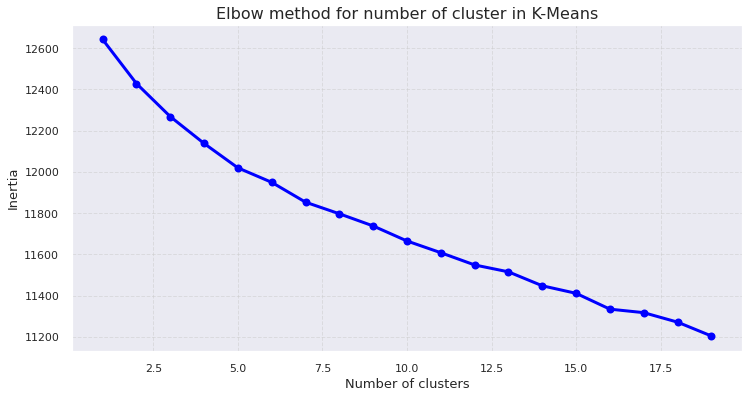

In [ ]:
fig, ax = plt.subplots(figsize=(12,6))
plt.title('Elbow method for number of cluster in K-Means', fontsize=16)
plt.plot(range(1, 20), dist,'bo-', linewidth=3, color='blue', markersize=8)
plt.xlabel('Number of clusters', fontsize=13)
plt.ylabel('Inertia', fontsize=13)
plt.grid(which='both', color='#cccccc', linestyle='--', alpha=0.5)
plt.show()

It looks like the optimal number of clusters would be somewhere beween 8-15. To refine our choice, we use similar plot from yellowbrick, that is faster and also has fit time line that helps with selecting the number of clusters.  

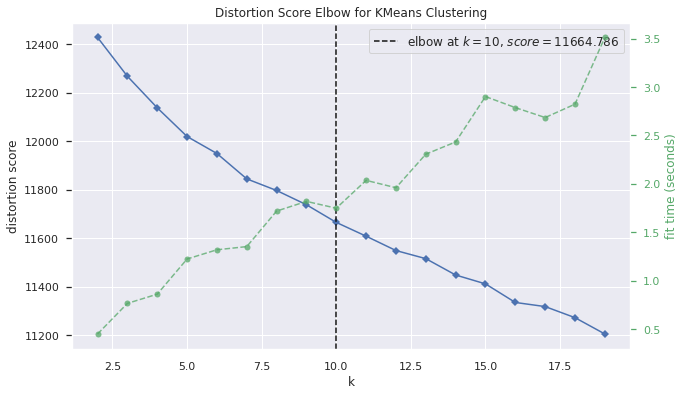

In [ ]:
# https://www.scikit-yb.org/en/latest/api/cluster/elbow.html
# Elbow Method for K means
model = KMeans(init='k-means++', n_init=10, max_iter=300, random_state=42)
fig, ax = plt.subplots(figsize=(10,6))
elbow_vis = KElbowVisualizer(model, k=(2,20), timings=True)
elbow_vis.fit(tfidf_vecs)
elbow_vis.show()

By default it uses distortion metric, which computes the sum of squared distances from each point to the assigned centroid. And we see that the suggested number of clusters is 10.

To confirm our choice, we will look at the Silhouette score

In [ ]:
# compute avg silhouette score for each number of clusters
# use smple size=1000 to speed up
kmeans_k = [KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=100,\
                   random_state=42).fit(tfidf_vecs) for k in range (1, 20)]
silhouette_scores = [silhouette_score(tfidf_vecs, model.labels_, metric='euclidean',sample_size=1000)\
                     for model in kmeans_k[1:]]

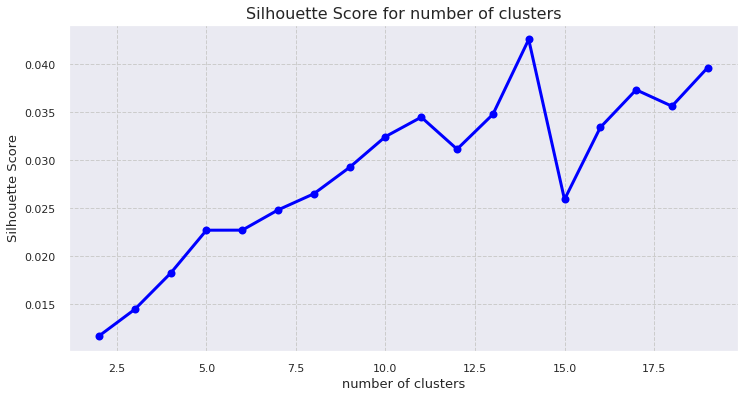

In [ ]:
# plot avg Silhouette Score
fig, ax = plt.subplots(figsize=(12,6))
plt.title('Silhouette Score for number of clusters', fontsize=16)
plt.plot(range(2,20), silhouette_scores, 'bo-', color='blue', linewidth=3, markersize=8, alpha=0.7)
plt.xlabel('number of clusters', fontsize=13)
plt.ylabel('Silhouette Score', fontsize=13)
plt.grid(which='major', color='#cccccc', linestyle='--')
plt.show()

Probably the best choice would be 11 clusters as the score reach realatively high score, after each it drops. At 14 it reaches its maximum, but we see the drops before and after. Let's investigate the plot produced by yellowbrick package to confirm.

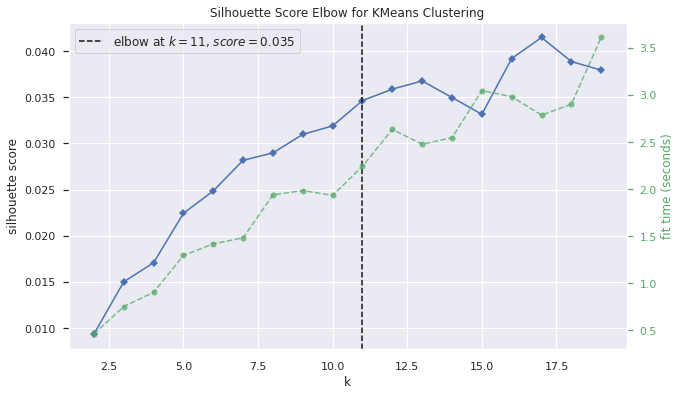

In [ ]:
# Silhouette Score for K means
model = KMeans(init='k-means++', n_init=10, max_iter=100,\
                   random_state=42)
fig, ax = plt.subplots(figsize=(10,6))
visualizer = KElbowVisualizer(model, k=(2,20),metric='silhouette', timings=True)
visualizer.fit(tfidf_vecs)
visualizer.show()
plt.show()

Silhouette Score that is a mean ratio of intra-cluster and nearest-cluster distance suggests that 11 would be optimal number of clusters. However, we see that the values are small in all choices, it might be relevant to the fact that the silhouette score assumes that all points are assigned to a cluster, and if we have somepoints that cannot be assigned, it can affect the score.

Let's investigate silhouette plots to check the allocation between different clusters and assosiated score to pick the final number of clusters. We will check results of K-Means with 11 clusters and a few values that are close to 11 to compare.

In order to visualize our clusters, we have to reduce the dimension to 2. We will try UMAP and PCA for comparison purposes.

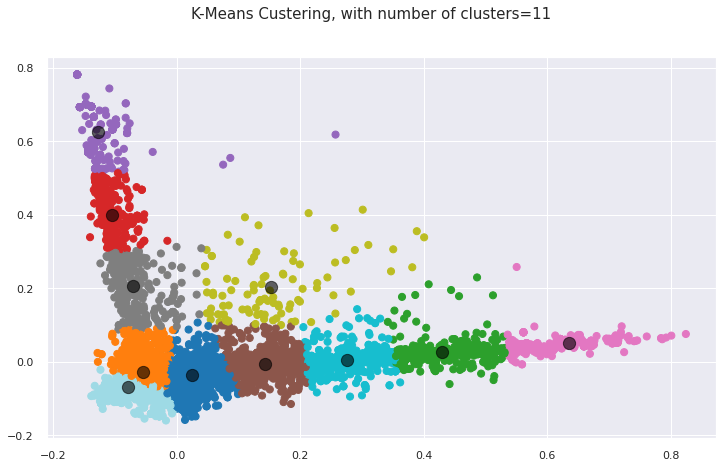

In [ ]:
pca = PCA(n_components=2)
scatter_plot_points = pca.fit_transform(tfidf_vecs.toarray())

num_clusters = 11
km = KMeans(n_clusters=num_clusters, init='k-means++', max_iter=600, random_state=42)
fitted = km.fit(scatter_plot_points)
predictions = km.predict(scatter_plot_points)

fig, ax = plt.subplots(figsize=(12,7))
plt.suptitle("K-Means Custering, with number of clusters={}".format(num_clusters), fontsize=15)
plt.scatter(scatter_plot_points[:, 0], scatter_plot_points[:, 1], c=predictions, s=50, cmap='tab20')

centers = fitted.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1],c='black', s=150, alpha=0.6)
plt.show()

We see that all clusters are somewhat compactly located and comparable sizes, except for lime green in the middle, that has points that are scattered around.

We will plot clusters and assosiated silhouette plots for the selected number of clusters and for a few clusters that near to comparision purposes.

In [ ]:
# Taken from the SciKit Learn website examples
# https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html

def make_silhouette(X_in):
    range_n_clusters = [5, 7, 8, 10, 11, 12, 13]
    for n_clusters in range_n_clusters:
        # Create a subplot with 1 row and 2 columns
        fig, (ax1, ax2) = plt.subplots(1, 2)
        fig.set_size_inches(18, 5)

        # The silhouette coefficient can range from -1, 1 but in this example all
        # lie within [-0.1, 1]
        ax1.set_xlim([-0.1, 1])
        # The (n_clusters+1)*10 is for inserting blank space between silhouette
        # plots of individual clusters, to demarcate them clearly.
        ax1.set_ylim([0, len(X_in) + (n_clusters + 1) * 10])

        clusterer = KMeans(n_clusters=n_clusters, random_state=42)
        cluster_labels = clusterer.fit_predict(X_in)

        # The silhouette_score gives the average value for all the samples.
        # This gives a perspective into the density and separation of the formed
        # clusters
        silhouette_avg = silhouette_score(X_in, cluster_labels)
        print("For n_clusters =", n_clusters,
              "The average silhouette_score is :", silhouette_avg)

        # Compute the silhouette scores for each sample
        sample_silhouette_values = silhouette_samples(X_in, cluster_labels)

        y_lower = 10
        for i in range(n_clusters):
            # Aggregate the silhouette scores for samples belonging to cluster i, and sort them
            ith_cluster_silhouette_values = \
                sample_silhouette_values[cluster_labels == i]

            ith_cluster_silhouette_values.sort()

            size_cluster_i = ith_cluster_silhouette_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = cm.nipy_spectral(float(i) / n_clusters)
            ax1.fill_betweenx(np.arange(y_lower, y_upper),
                              0, ith_cluster_silhouette_values,
                              facecolor=color, edgecolor=color, alpha=0.7)

            # Label the silhouette plots with their cluster numbers at the middle
            ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

            # Compute the new y_lower for next plot
            y_lower = y_upper + 10  # 10 for the 0 samples

        ax1.set_title("The silhouette plot for the various clusters.")
        ax1.set_xlabel("The silhouette coefficient values")
        ax1.set_ylabel("Cluster label")

        # The vertical line for average silhoutte score of all the values
        ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
        ax1.set_yticks([])  # Clear the yaxis labels / ticks
        ax1.xaxis.grid(True)
        ax1.set_xticks([-0.2, 0, 0.2, 0.4, 0.6, 0.8, 1])

        # Draw white circles at cluster centers
        centers = clusterer.cluster_centers_

        # 2nd Plot showing the actual clusters formed
        colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)

        ax2.scatter(X_in[:, 1], X_in[:, 0], marker='.', s=100, lw=0, alpha=0.7, c=colors)
        ax2.set_title("The visualization of the clustered data.")
        ax2.set_xlabel('X_0')
        ax2.set_ylabel('X_1')
        ax2.grid(False)

        plt.suptitle(("Silhouette analysis for KMeans clustering on sample data "
                      "with n_clusters = %d" % n_clusters), fontsize=14, fontweight='bold')
        plt.show()


For n_clusters = 5 The average silhouette_score is : 0.7130084790825837


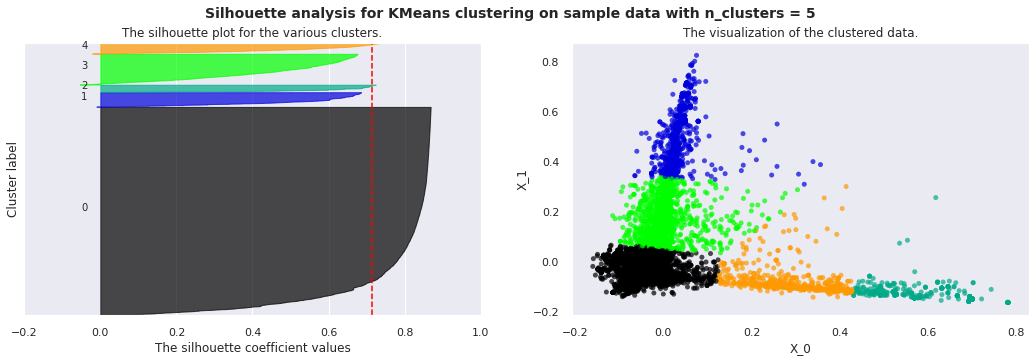

For n_clusters = 7 The average silhouette_score is : 0.5509673993367005


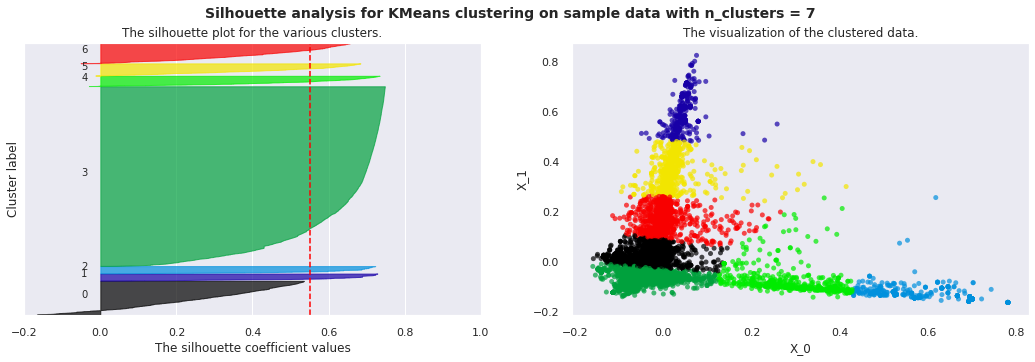

For n_clusters = 8 The average silhouette_score is : 0.5688261996909021


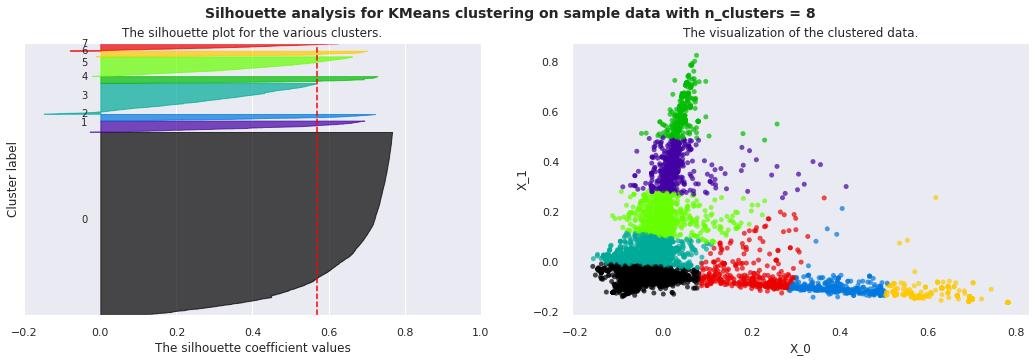

For n_clusters = 10 The average silhouette_score is : 0.4400964433520572


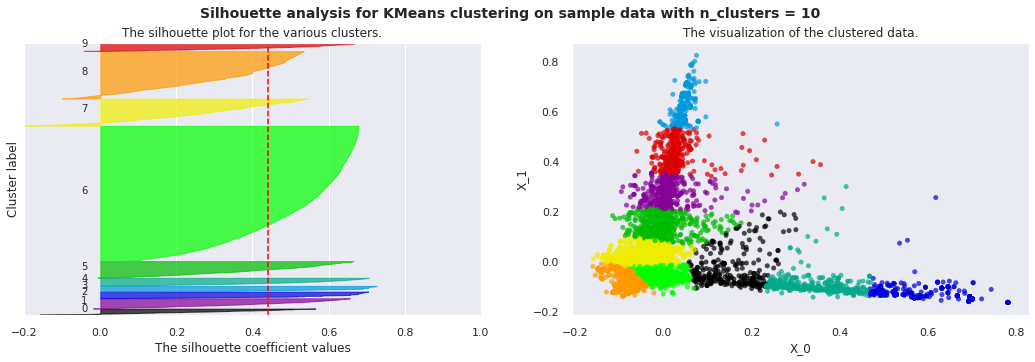

For n_clusters = 11 The average silhouette_score is : 0.45142360470873666


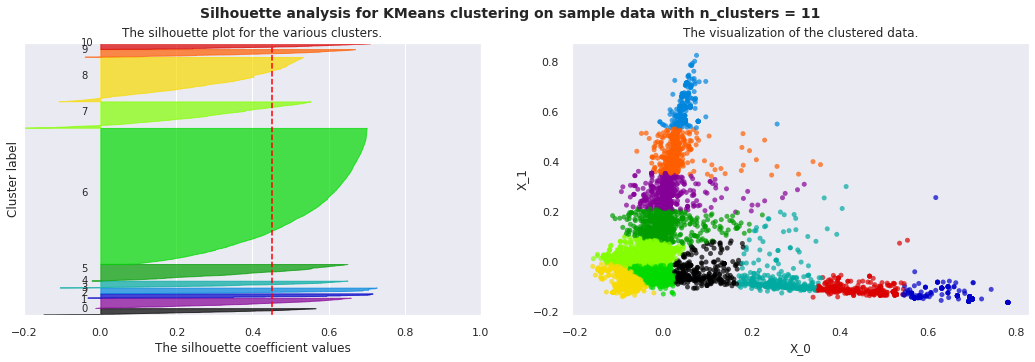

For n_clusters = 12 The average silhouette_score is : 0.4571731036871641


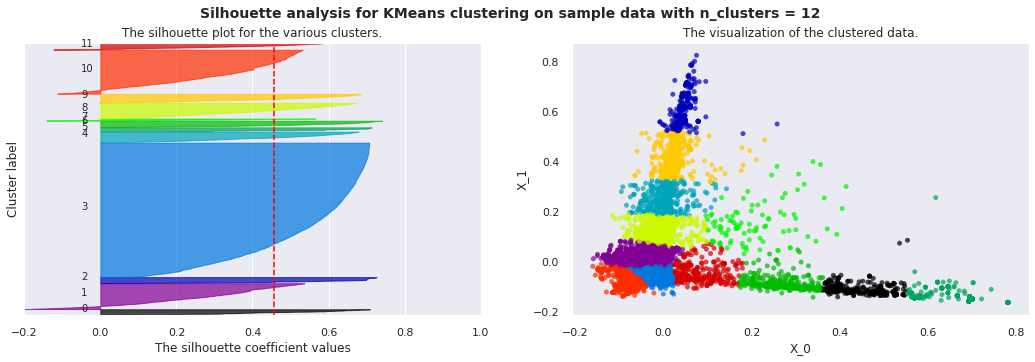

For n_clusters = 13 The average silhouette_score is : 0.454006529923687


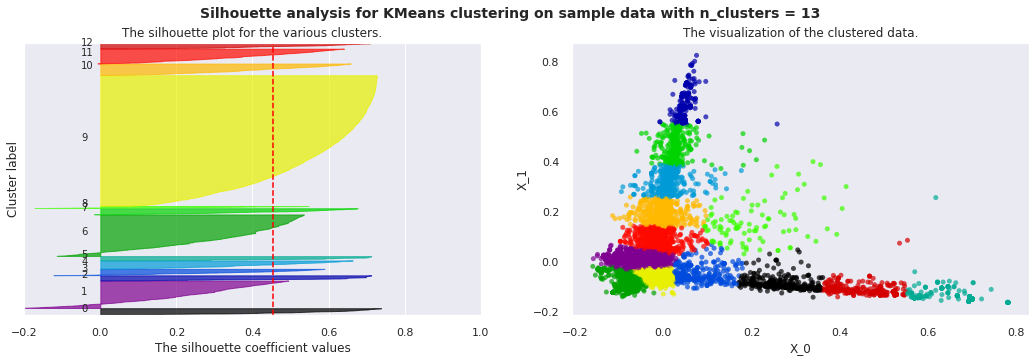

In [ ]:
# run the silhouette plotting function
make_silhouette(scatter_plot_points)

In [ ]:
umap_vecs = umap.UMAP(n_neighbors=20, random_state=42).fit_transform(tfidf_vecs)

For n_clusters = 5 The average silhouette_score is : 0.37487528


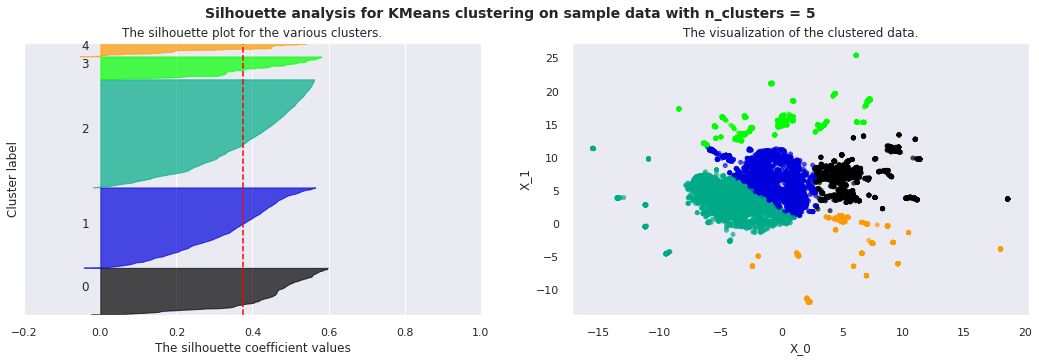

For n_clusters = 7 The average silhouette_score is : 0.374583


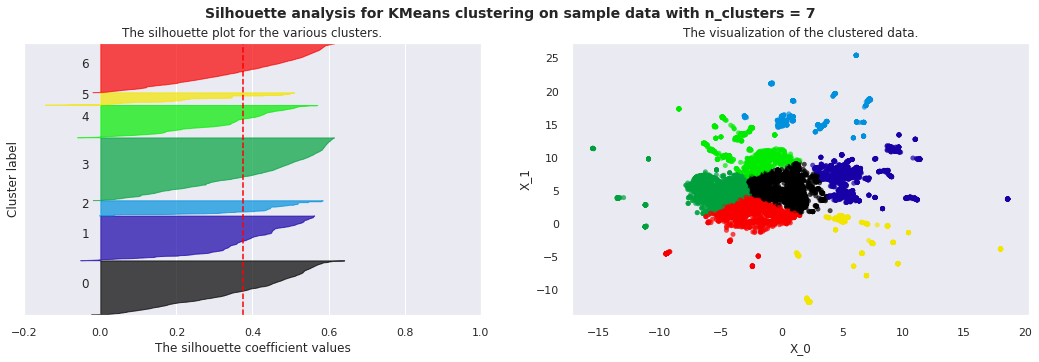

For n_clusters = 8 The average silhouette_score is : 0.38380456


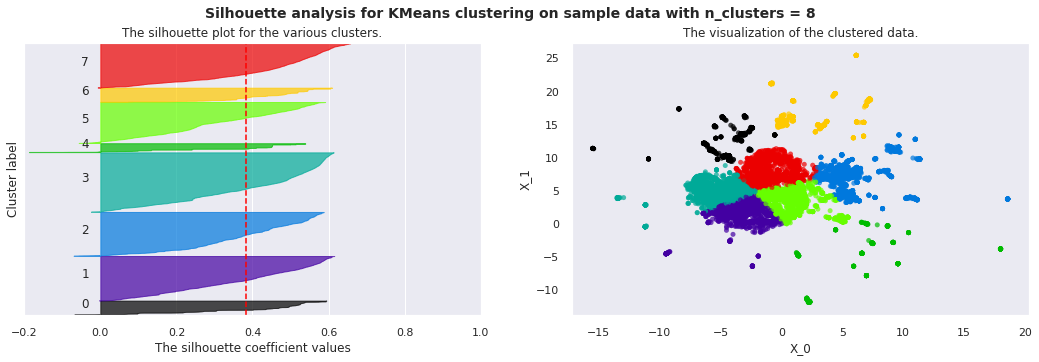

For n_clusters = 10 The average silhouette_score is : 0.39875743


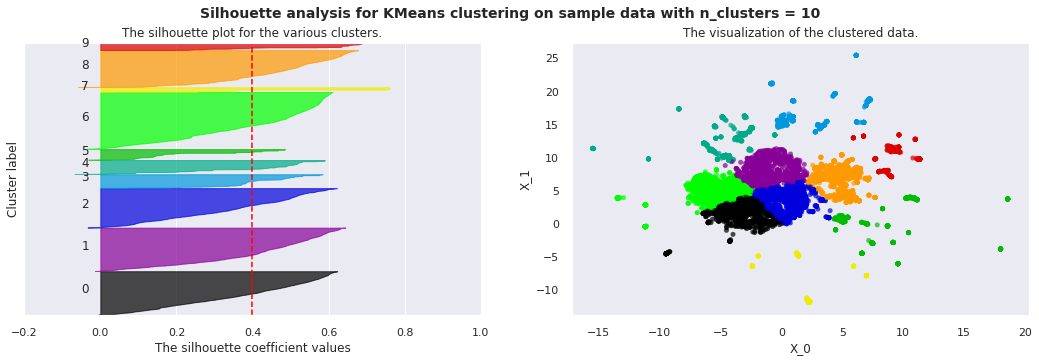

For n_clusters = 11 The average silhouette_score is : 0.4016968


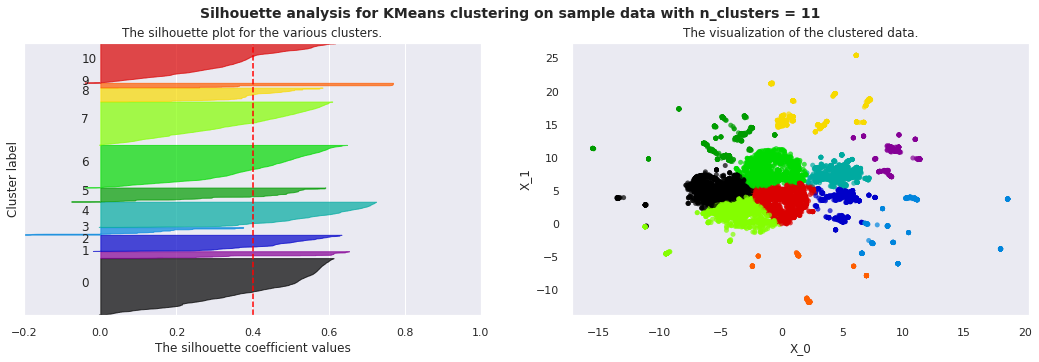

For n_clusters = 12 The average silhouette_score is : 0.41290122


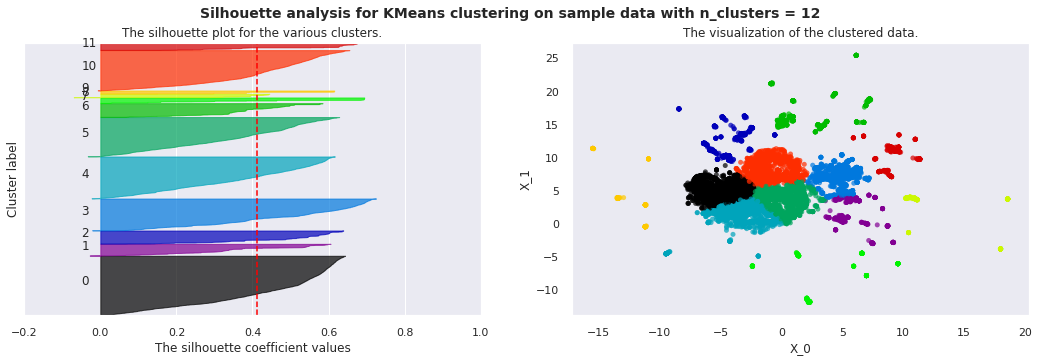

For n_clusters = 13 The average silhouette_score is : 0.38995457


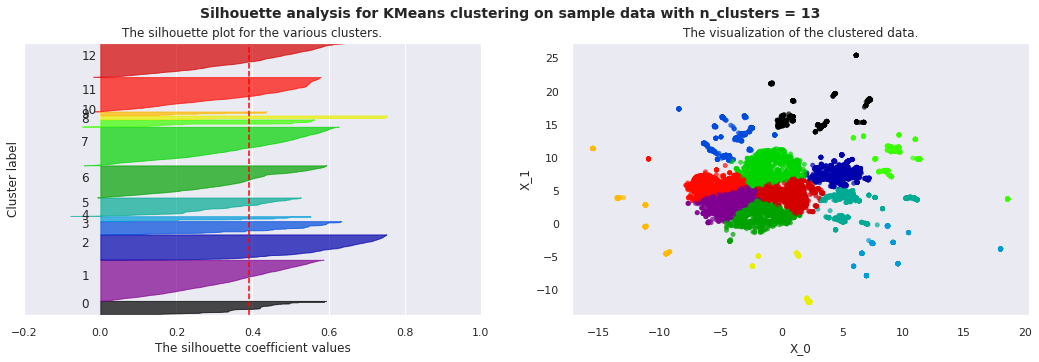

In [ ]:
# visuals using UMAP for dimentionality reduction
make_silhouette(umap_vecs)

**From plot using PCA components:**   
The highest score 0.71 is with 5 clusters.  
However, one cluster appears to be very large and has a high score of ~0.9, where the remaining 4 have scores below 0.7  
10 and 11 cluster look relatively similar.
12 and 13 look similar with a bit higher score compared to 10 and 11.   
**From plot using UMAP components:**  

Overall clusters look more evenly allocated.   
5, 7, 8 clusters have a low score.   
10 and 11 have similar score. However, cluster 3 in the choice of 11 clusters have a high number of misclassifications (negative “tail”) and this cluster have low scores. Our choice would be towards 10 clusters.   
12 has a higher score compared to 10, 11, 13.   
**To summarize:**  
we will try 10 clusters and 12, and evaluated produced labels.


We use the average silhouette score to confirm and finetune our observation from the "elbow" method. Silhouette score shows how similar an object is to its own cluster. That means the higher the score the better.

In [ ]:
num_clusters = 10
km10 = KMeans(n_clusters=num_clusters, random_state=42)
%time km10.fit(tfidf_vecs)
clusters10 = km10.labels_.tolist()
predictions = km10.predict(tfidf_vecs)

CPU times: user 3.43 s, sys: 143 ms, total: 3.58 s
Wall time: 2 s


In [ ]:
# distribution of observations per cluster
km_labels10 = km10.labels_.tolist()
depr_excl_cl['km_labels10'] = predictions
depr_excl_cl['km_labels10'].value_counts()

3    6538
2    1159
1    1078
5    1063
8     756
4     731
0     574
6     505
9     285
7     195
Name: km_labels10, dtype: int64

We see that we have one very large cluster (#3) that has 6538 observations.

In [ ]:
# to get the most descriptive words for each luster
def get_top_features_cluster(tfidf_vecs, predictions, n_feats):
    labels = np.unique(predictions)
    dfs = []
    for label in labels:
        id_temp = np.where(predictions==label) # indices for each cluster
        x_means = np.mean(tfidf_vecs[id_temp], axis = 0) # returns average score across cluster
        sorted_means = np.argsort(x_means)[::-1][:n_feats]
        features = tfidf.get_feature_names()
        best_features = [(features[i], x_means[i]) for i in sorted_means]
        df = pd.DataFrame(best_features, columns = ['features', 'score'])
        dfs.append(df)
    return dfs

In [ ]:
dfs = get_top_features_cluster(tfidf_vecs.toarray(), km_labels10 , 10)
for i in range(10):
  print("Cluster {}".format(i))
  print(dfs[i])
  print("-" * 30)

Cluster 0
   features     score
0  substanc  0.249550
1      abus  0.248893
2   alcohol  0.207984
3    depend  0.204233
4      drug  0.126905
5     month  0.083940
6   current  0.083360
7    within  0.057695
8      past  0.054619
9       use  0.047472
------------------------------
Cluster 1
        features     score
0         disord  0.374648
1        bipolar  0.186961
2        psychot  0.125382
3  schizophrenia  0.087698
4       diagnosi  0.070360
5        histori  0.054030
6        current  0.044253
7   schizoaffect  0.043190
8      psychiatr  0.038350
9       psychosi  0.038008
------------------------------
Cluster 2
      features     score
0        medic  0.226880
1       condit  0.072909
2          ill  0.068004
3      unstabl  0.053174
4          use  0.045489
5  antidepress  0.039032
6        studi  0.038445
7      current  0.034047
8   psychotrop  0.031559
9        month  0.029606
------------------------------
Cluster 3
   features     score
0  particip  0.020832
1     stu

We see that cluster 7 and cluster 9 have some overlapping words, like pregnant, women, breastfeed. This indicates on potentially incorrect clustering or maybe too many clusters.

In [ ]:
n_clusters = 10
for i in range(n_clusters):
    # all the points belong to cluster
    c_i = np.where(km10.labels_ == i)[0].tolist()
    n_i = len(c_i)
    # random 5 samples from cluster
    sample_i = np.random.choice(n_i, 5)
    print("5 criteron samples assigned to cluster ", i)
    print("-" * 60)
    for s_i in sample_i:
      print(depr_excl_cl.iloc[depr_excl_cl.groupby(['km_labels10']).groups[i][s_i]]['criterion'])
    print("_" * 60)

5 criteron samples assigned to cluster  0
----------------------------------------------------------------------
Subjects with a history of DSM-IV drug dependency or abuse (except for caffeine or nicotine dependence) within the preceding 3 months 
Drug or alcohol abuse or dependence within the preceding 3 months (given that this might otherwise contribute to their symptoms, however, a rather narrow time period was chosen such as to allow participation by individuals with a history of substance abuse or dependence problems that could be secondary to their PTSD, and to more closely approximate patients seen in real-world settings);
alcohol or drug dependency
Alcohol or substance abuse or dependence within the past six months
Severe alcohol or substance use disorder
______________________________________________________________________
5 criteron samples assigned to cluster  1
----------------------------------------------------------------------
Organic mental disorder
Patients with a hi

Evaluation Summary:  
Cluster 0: all observations are consistent, groupped by "substance and alcohol abuse"  
Cluster 1: all observations are consistent, groupped by "current mental illness condition/disorder"(most of the checked cases are bipolar disorder or schizophrenia)  
Cluster 2: all observations are consistent, grouped by "some medical illness/condition"   
Cluster 3: samples are more diverse, but somewhat can be grouped by "do not fit as life expectancy, not being available geographically, having allergy..." As the cluster was the largest one, it's explainable that we see more diversity here, but all criterion are distinct from other identified clusters.  
Cluster 4: all samples are  consistent, grouped by "risk of suicide"  
Cluster 5: all samples are consistent, grouped by "currently being under some sort of treatment" even though the conditions vary.  
Cluster 6: all samples are somewhat consistent, grouped by "not being able to provide consent/being cognitive impaired"    
Cluster 7: all samples are consistent, grouped by "current or planned pregnancy"  
Cluster 8: samples are grouped by realtionship to a "history" of something/chronical condition. It would be great if the model would look closely to the history object instead of grouping history cases together.  
Cluster 9: all samples are consistent as they are grouped by "pregnancy", but this cluster is redundant as it's the same as cluster 7.

Overall the results are good for having 10 clusters. However, we see one redundant/douplicative cluster. We will try 12 clusters now as our previous analysis suggested.

In [ ]:
num_clusters = 12
km12 = KMeans(n_clusters=num_clusters, random_state=42)
%time km12.fit(tfidf_vecs)
predictions = km12.predict(tfidf_vecs)

CPU times: user 3.95 s, sys: 143 ms, total: 4.1 s
Wall time: 2.32 s


In [ ]:
# distribution of observations per cluster
km_labels12 = km12.labels_.tolist()
depr_excl_cl['km_labels12'] = km_labels12
depr_excl_cl['km_labels12'].value_counts()

6     7359
3     1183
5     1159
2      712
8      594
0      538
10     287
4      245
1      207
11     204
7      200
9      196
Name: km_labels12, dtype: int64

In [ ]:
n_clusters = 12
for i in range(n_clusters):
    # all the points belong to cluster
    c_i = np.where(km12.labels_ == i)[0].tolist()
    n_i = len(c_i)
    # random 5 samples from cluster
    sample_i = np.random.choice(n_i, 5)
    print("5 criteron samples assigned to cluster ", i)
    print("-" * 60)
    for s_i in sample_i:
      print(depr_excl_cl.iloc[depr_excl_cl.groupby(['km_labels12']).groups[i][s_i]]['criterion'])
    print("_" * 60)

5 criteron samples assigned to cluster  0
----------------------------------------------------------------------
Another medical condition associated with significant pain (e.g., diabetic neuropathy, systemic lupus erythematosus, Rheumatoid arthritis, severe degenerative joint disease)
Major neurological disease
Diagnosis of probable or definite dementia (Alzheimer's Disease, Vascular Dementia, Parkinson's disease, etc.) (Method of ascertainment: SCID, clinical interview, MMSE)
Presence of co-morbid medical conditions not limited to but including cardiovascular (e.g., history of acute coronary event, stroke) and neurological diseases (e.g., Parkinson's disease), as well as pain disorders;
respiratory disease
______________________________________________________________________
5 criteron samples assigned to cluster  1
----------------------------------------------------------------------
Severe psychiatric condition (e.g., current acute psychosis, past or current hypomania/mania) base

Cluster 9 and 10 are the same (pragnancy). We got two distinct clusters that group observation based on "ability to communicate and speak English" and "mental disorder, specificly psychosis". Overall, we can say that we have a few more cases of misclassification compared to having 10 clusters, eventhough we got two distinct clusters.   
However, results from both models suggested that we have redundant cluster. We will try to reduce number of clusters to 9, and if the results will  not be satisfactory, we will move to another model type.

In [ ]:
num_clusters = 9
km9 = KMeans(n_clusters=num_clusters, random_state=42)
%time km9.fit(tfidf_vecs)
predictions = km9.predict(tfidf_vecs)
km_labels9 = km9.labels_.tolist()
depr_excl_cl['km_labels9'] = km_labels9

CPU times: user 3.42 s, sys: 38.7 ms, total: 3.46 s
Wall time: 1.91 s


In [ ]:
n_clusters = 9
for i in range(n_clusters):
    # all the points belong to cluster
    c_i = np.where(km9.labels_ == i)[0].tolist()
    n_i = len(c_i)
    # random 5 samples from cluster
    sample_i = np.random.choice(n_i, 5)
    print("5 criteron samples assigned to cluster ", i)
    print("-" * 60)
    for s_i in sample_i:
      print(depr_excl_cl.iloc[depr_excl_cl.groupby(['km_labels9']).groups[i][s_i]]['criterion'])
    print("_" * 60)

5 criteron samples assigned to cluster  0
----------------------------------------------------------------------
shift workers, regular night shift workers, frequent time zone fliers (such as crew members on international flights) 
ICD-10 diagnosis of depression F32 or F33 and psychotic episodes
Presence of a transplanted solid organ (with the exception of a corneal transplant > 3 months prior to screening).
Received surgery or radiation therapy in 4 weeks
a SCID-I diagnosis of:
______________________________________________________________________
5 criteron samples assigned to cluster  1
----------------------------------------------------------------------
Current diagnosis of substance dependence (but not abuse)
addicted to alcohol
illicit drug use or alcohol abuse
are currently under the influence of alcohol or other recreational drugs
Hazardous substance use, substance dependency or substance use disorder (assessed using the DAST-10 and AUDIT-C) 
_________________________________

We did not improve the results from case when we have 12 or 10 clusters.   
Either we selected the number of cluster incorrectly, or vectorizer was not appropriate, or this model is not a good model for this data.   
We are moving to another model.

## Hierarchical methods

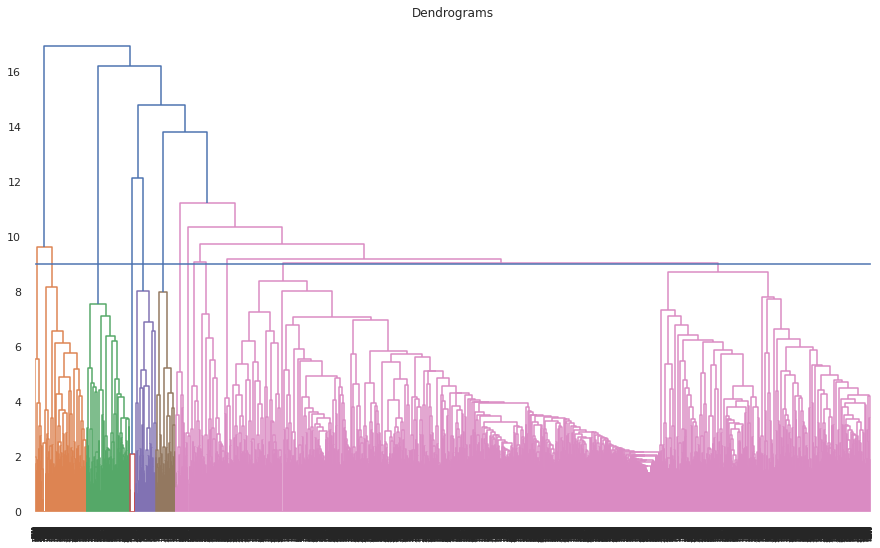

In [ ]:
# Dendogram for Heirarchical Clustering - Ward
plt.figure(figsize=(15, 9))
plt.title("Dendrograms")
dend = shc.dendrogram(shc.linkage(tfidf_vecs.toarray(), method='ward'))
plt.axhline(y=9)

The cut that covers maximum vertical distance would be somewhere at y=13, which will give us 5 clusters. But it will give 1-2 clusters that would be very large and somewhat mixed in content.   

If we make a cut at y=9, we will get 13 clusters which is a managable number. However, we see in the "pink" area that the better cut would be somewhere at y=3, but it will result in a large number of clusters.   
Having 13 clusters means we will have one a few extremly large clusters with possibly mixed observations that should be divided into more granular level.

In [ ]:
h_cluster = AgglomerativeClustering(n_clusters=13, affinity='euclidean', linkage='ward')  # n=13 from dendrogram above
agg_cl=h_cluster.fit_predict(tfidf_vecs.toarray())

In [ ]:
agg_labels = h_cluster.labels_.tolist()
depr_excl_cl['agg_labels'] = agg_labels
depr_excl_cl['agg_labels'].value_counts()

2     6575
0     3261
1      672
5      661
8      358
3      318
4      300
12     166
6      148
9      135
10     116
11      94
7       80
Name: agg_labels, dtype: int64

In [ ]:
for i in range(13):
    # all the points belong to cluster
    c_i = np.where(h_cluster.labels_ == i)[0].tolist()
    n_i = len(c_i)
    # random 5 samples from cluster
    sample_i = np.random.choice(n_i, 5)
    print("5 criteron samples assigned to cluster ", i)
    print("-" * 60)
    for s_i in sample_i:
      print(depr_excl_cl.iloc[depr_excl_cl.groupby(['agg_labels']).groups[i][s_i]]['criterion'])
    print("_" * 60)

5 criteron samples assigned to cluster  0
--------------------------------------------------
kidney disease
No acute medical illness or dementia 
 Individuals are excluded from the study if: 1. The traumatic event occurred in the past month 2. They are currently suicidal or homicidal, as indicated by a positive screen on the C-SSRS Question 4 or Question 5 at intake. 3. They have a history of psychosis or mania 4. They have not been on a stable dose of medication for at least one month 5. They have dietary patterns not representative of normal populations (e.g., vegetarian, vegan, gluten-free) 6. They made changes to the diet in the past month or are planning to make changes over the course of therapy 7. They have completed an evidence-based PTSD treatment in the past 3 months or are currently receiving an evidence-based PTSD treatment 8. They have mental retardation or significant cognitive impairment that would prevent them from engaging in CPT 9. They have a serious or unstable medi

We see that hierarchical model performed worse than K-Means.

## HDBSCAN Model

As our word embeding vector has high dementionality. We will use UMAP to reduce demention.

In [ ]:
tfidf_vecs.toarray().shape

(12884, 6200)

In [ ]:
umap_vecs = umap.UMAP(n_neighbors=40, metric='cosine', random_state=42).fit_transform(tfidf_vecs)

In [ ]:
# use default parameters
clusterer = hdbscan.HDBSCAN(min_cluster_size=15, min_samples=15, prediction_data=True).fit(umap_vecs)

Check what number of clusters and proportion of noise we have with untuned model. We want to have a somewhat managable number of clusters.

In [ ]:
# check number of clusters and cost assisiated with it
cluster_labels = clusterer.labels_
label_count = len(np.unique(cluster_labels))
total_num = len(clusterer.labels_)
noise_proportion = (np.count_nonzero(clusterer.probabilities_ < 0.05)/total_num) # we want to minimize number of insignifican probabilities (<5%)
non_noise_rate = len(cluster_labels[cluster_labels!=-1])/umap_vecs.shape[0] # we want to maximize number of not noise observayion
label_count, noise_proportion, non_noise_rate

(141, 0.3540825830487426, 0.6516609748525303)

Based on our previous experience with K-Means and reading samples of the text, we can conclude that 141 clusters will be overwhelming and hard to check. Additionally, we know taht HDBSCAN is good in separating the noise, but in our case, we want to try to cluster all records. We want to try to minimize the noise or check soft clustering feature. We will try to tune parameters for HDBSCAN.

We will check some reasonable values and as eveluation will use validity score to pick the reasonably optimal ones.

We can reduce the `min_sample` that increase the concetrating points together. It might not have a good effect on visual representation, but is beneficial for clustering. Since we reduce the number of samples and want to reduce number of clusters for a reasonable amount, we will need to increase `min_cluster_size` as we have a lot of observations.

In [ ]:
# use validity score for hyperparameters tuning
hdb = hdbscan.HDBSCAN(gen_min_span_tree=True).fit(umap_vecs)

param_dist = {'min_samples': [10,30,50,60,70,80,100,120],
              'min_cluster_size':[30,50,100,120,150,200,250,280,300,400,500],
              'cluster_selection_method' : ['eom','leaf', 'cosine'],
              'metric' : ['euclidean','manhattan']
             }

# https://readthedocs.org/projects/hdbscan/downloads/pdf/latest/
validity_scorer = make_scorer(hdbscan.validity.validity_index,greater_is_better=True)

random_search = RandomizedSearchCV(hdb,
                                   param_distributions=param_dist,
                                   n_iter=20,
                                   scoring=validity_scorer,
                                   random_state=55)
random_search.fit(umap_vecs)


print("Best Parameters",random_search.best_params_)
print("DBCV score :", random_search.best_estimator_.relative_validity_)

Best Parameters {'min_samples': 70, 'min_cluster_size': 400, 'metric': 'euclidean', 'cluster_selection_method': 'eom'}
DBCV score : 0.1745460299993168


The score indicates how well clusters are separated, we didn't get a very high score, but we will try this parameters as a starting point.  

In [ ]:
clusterer2 = hdbscan.HDBSCAN(min_cluster_size=400, min_samples=70,\
                            metric='euclidean', cluster_selection_method='eom',\
                            prediction_data=True).fit(umap_vecs)

cluster_labels = clusterer2.labels_
label_count = len(np.unique(cluster_labels))
total_num = len(clusterer2.labels_)
noise_proportion = (np.count_nonzero(clusterer2.probabilities_ < 0.05)/total_num)
non_noise_rate = len(cluster_labels[cluster_labels!=-1])/umap_vecs.shape[0]
label_count, noise_proportion, non_noise_rate

(7, 0.5760633343682087, 0.4239366656317914)

We were able to reduce the number of clusters, however the number of points assigned to the noise is very large. Let's check the results and we will try to reduce `min_samples`.  

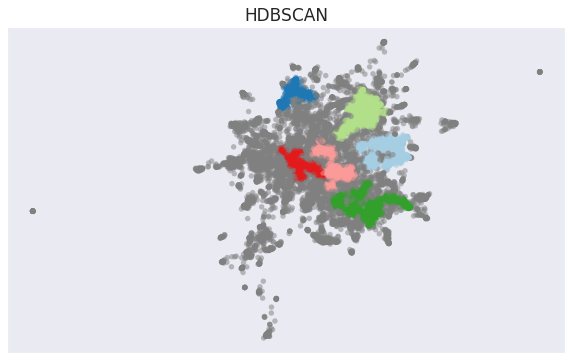

In [ ]:
# to visualize clusters
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title('HDBSCAN', fontsize=17)
color_palette = sns.color_palette('Paired', 7)
cluster_colors = [color_palette[x] if x >= 0
                  else (0.5, 0.5, 0.5)
                  for x in clusterer2.labels_]
cluster_member_colors = [sns.desaturate(x, p) for x, p in
                         zip(cluster_colors, clusterer2.probabilities_)]
plt.scatter(*umap_vecs.T, s=30, linewidth=0, c=cluster_colors, alpha=0.5)
frame = plt.gca()
frame.axes.get_xaxis().set_visible(False)
frame.axes.get_yaxis().set_visible(False)
plt.show()

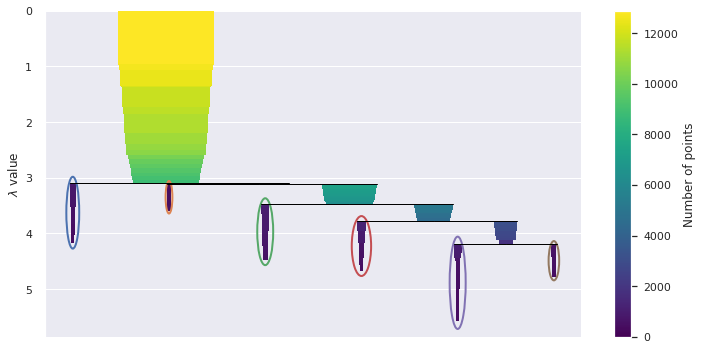

In [ ]:
# to check the condensed try and clusters allocation
fig, ax = plt.subplots(figsize=(12, 6))
clusterer2.condensed_tree_.plot(select_clusters=True, selection_palette=sns.color_palette())
plt.show()

In [ ]:
hdb_labels = clusterer2.labels_.tolist()
depr_excl_cl['hdb_labels'] = hdb_labels
depr_excl_cl['hdb_labels'].value_counts()

-1    7422
 3    1296
 4    1074
 2    1067
 0     863
 5     708
 1     454
Name: hdb_labels, dtype: int64

From the plots and observations distribution we see that we have 7422 points assigned as noise (cluster "-1").   
Let's check the results.

In [ ]:
for i in range(-1,6):
    # all the points belong to cluster
    c_i = np.where(clusterer2.labels_ == i)[0].tolist()
    n_i = len(c_i)
    # random 5 samples from cluster
    sample_i = np.random.choice(n_i, 5)
    print("5 criteron samples assigned to cluster ", i)
    print("-" * 60)
    for s_i in sample_i:
      print(depr_excl_cl.iloc[depr_excl_cl.groupby(['hdb_labels']).groups[i][s_i]]['criterion'])
    print("_" * 60)

5 criteron samples assigned to cluster  -1
--------------------------------------------------
Have regularly engaged in moderate (activity that makes you breathe somewhat harder than normal; may include carrying light loads, bicycling at a regular pace, fast walking, tennis, easy swimming, or popular or folk dancing) or vigorous (activity that causes heavy breathing, sweating, rapid fatigue; it can only be sustained for very short periods of time, like running or swimming strongly) physical activity at least 3-5 days per week (on average) within the past 4 weeks. Pregnant women will not be excluded from this study because the study intervention(s) pose no risk of potential for teratogenic or abortifacient effects. In fact, gentle yoga practice is quite safe for pregnant women and poses can be slightly modified, if needed. The anticipated number of pregnant women eligible to enroll is minimal. 
not living in the study site 
Patients with areas of the skin that present some type of wound

Results look good and randomly checked samples seem to be correctly grouped. However, we have a large amount of "noise". "-1/noise" cluster is a mixe if different creterions. Additionaly, based on the text examination, splitting into more clusters would be beneficial to capture more details.

As we have to provide labels for each reacord as a part of this assignment. We will explore the "soft clustering" feature of HDBSCAN that takes the maximum of the probability of belonging to a cluster and make it "hard" label.

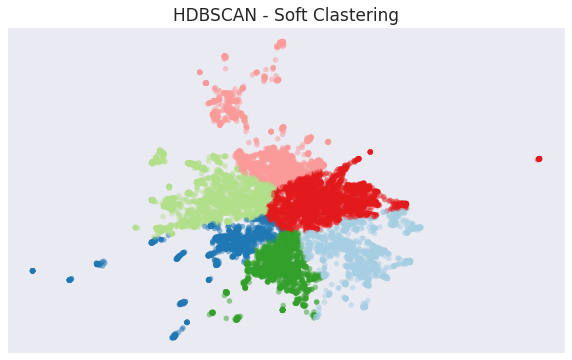

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title('HDBSCAN - Soft Clastering', fontsize=17)
soft_clusters = hdbscan.all_points_membership_vectors(clusterer2)
color_palette = sns.color_palette('Paired', 6)
cluster_colors = [color_palette[np.argmax(x)]
                  for x in soft_clusters]
plt.scatter(*umap_vecs.T, s=30, linewidth=0, c=cluster_colors, alpha=0.5)
frame = plt.gca()
frame.axes.get_xaxis().set_visible(False)
frame.axes.get_yaxis().set_visible(False)
plt.show()

We see that the clusters are well separated and there is no noise.

In [ ]:
soft_assignments = np.argmax(soft_clusters, axis=1)
hdb_soft_labels = soft_assignments.tolist()
depr_excl_cl['hdb_labels_soft'] = hdb_soft_labels
depr_excl_cl['hdb_labels_soft'].value_counts()

5    4124
3    2544
2    2242
4    1370
1    1363
0    1241
Name: hdb_labels_soft, dtype: int64

The allocation looks better, let's check the results.

In [ ]:
for i in range(6):
    # all the points belong to cluster
    c_i = np.where(clusterer2.labels_ == i)[0].tolist()
    n_i = len(c_i)
    # random 5 samples from cluster
    sample_i = np.random.choice(n_i, 5)
    print("5 criteron samples assigned to cluster ", i)
    print("-" * 60)
    for s_i in sample_i:
      print(depr_excl_cl.iloc[depr_excl_cl.groupby(['hdb_labels_soft']).groups[i][s_i]]['criterion'])
    print("_" * 60)

5 criteron samples assigned to cluster  0
--------------------------------------------------
Alcohol addiction
Respiratory problems
Smokers
F1x: Mental and behavioral disorders due to psychoactive substance use
History of substance abuse
__________________________________________________
5 criteron samples assigned to cluster  1
--------------------------------------------------
Suicidal ideation
Beck Depression Inventory score of at least 29 on two consecutive occasions
Significant risk of suicide based on clinical judgment, including common 
History of suicide attempts
Folstein Mini-Mental Status Exam (MMSE) of 17 or lower
__________________________________________________
5 criteron samples assigned to cluster  2
--------------------------------------------------
History of or current Axis 1 DSM-V psychiatric disorder (except depression or anxiety disorders such as specific phobia or social anxiety disorder for the MDD group and drug abuse subject to the criteria outlined below).The

Unfortunately, taking the argmax of the probability (soft clustering) didn't produce the expected results. We will make one more attempt to tune hyperparameters without soft clustering but this time try to illiminate the noise.

In [ ]:
clusterer3 = hdbscan.HDBSCAN(min_cluster_size=120, min_samples=2, prediction_data=True).fit(umap_vecs)
soft_clusters = hdbscan.all_points_membership_vectors(clusterer3)
cluster_labels = clusterer3.labels_
label_count = len(np.unique(cluster_labels))
total_num = len(clusterer3.labels_)
noise_proportion = (np.count_nonzero(clusterer3.probabilities_ < 0.05)/total_num)
non_noise_rate = len(cluster_labels[cluster_labels!=-1])/umap_vecs.shape[0]
label_count, noise_proportion, non_noise_rate

(7, 0.10190934492393666, 0.8980906550760633)

In [ ]:
soft_assignments = np.argmax(soft_clusters, axis=1)
hdb_soft_labels = soft_assignments.tolist()
depr_excl_cl['hdb_labels_soft_2'] = hdb_soft_labels
depr_excl_cl['hdb_labels_soft_2'].value_counts()

5    11339
2      484
4      380
3      273
1      233
0      175
Name: hdb_labels_soft_2, dtype: int64

We see that reducing the min number of samples let us reduce the noise, but the allocation of points is very dispropostionate. We have to allow some noise, or drasticaly increase the number of clusters, or this model/vector is not a good fit for this data set.

We conclude that K-Means produced the most reasonable results for the exclusion data set. One drawback is that it produce two identical clusters, which can be quickly fixed by combining them. We tried to fix out tf-idf vector to eliminate it by tweaking parameters, but it produces much worse quality of clusters.   

We would like to explore Glove vectors or use BERT, but for this time keeping K-Means as the best model for exclusion set.